In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
sys.path.append('../..')
from lo_circuit.minimal_swaps import *
from lo_circuit.fusion_network import *
from lo_circuit.fusion_order import *
from firstpassage.FPTCalculator import *
import random
import perceval as pcvl
import itertools
import networkx as nx

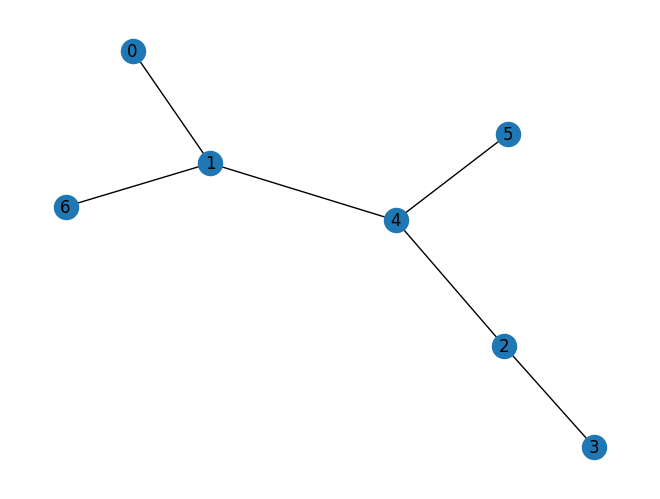

In [2]:
G = nx.Graph([(0, 1), (1, 4), (1, 6), (2, 3), (2, 4), (4, 5)])
nx.draw(G, with_labels=True)

In [4]:
T = get_spanning_tree(G,'dfs','max',False)
fusion_network = build_fusion_network_from_spanning_tree(T,0,G)
fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
print(fusion_order)

[(4, 9), (1, 12), (5, 6), (2, 3)]


in dfs for graph with nodes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14] fusion order [(4, 9), (1, 12), (5, 6), (2, 3)]


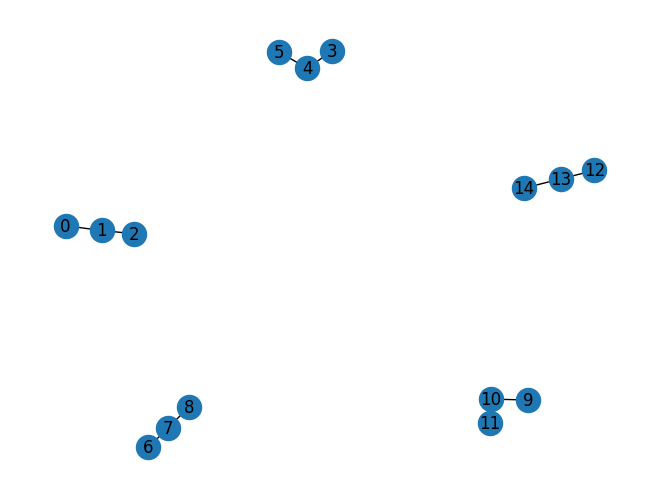

fusion  (4, 9)  success
in dfs for graph with nodes [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 14] fusion order [(4, 9), (1, 12), (5, 6), (2, 3)]


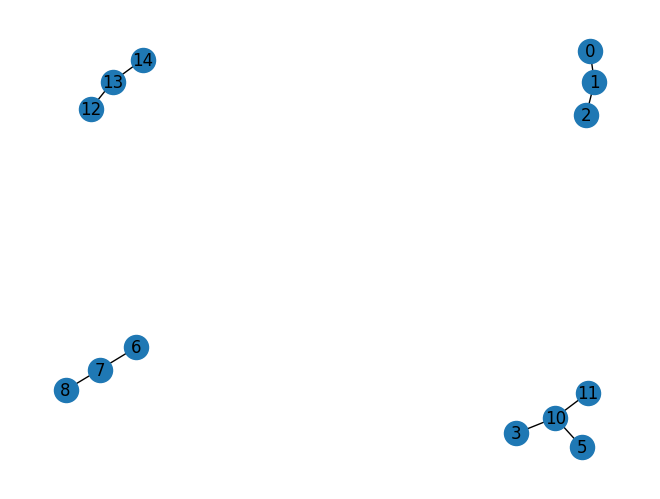

fusion  (1, 12)  success
in dfs for graph with nodes [0, 2, 3, 5, 6, 7, 8, 10, 11, 13, 14] fusion order [(4, 9), (1, 12), (5, 6), (2, 3)]


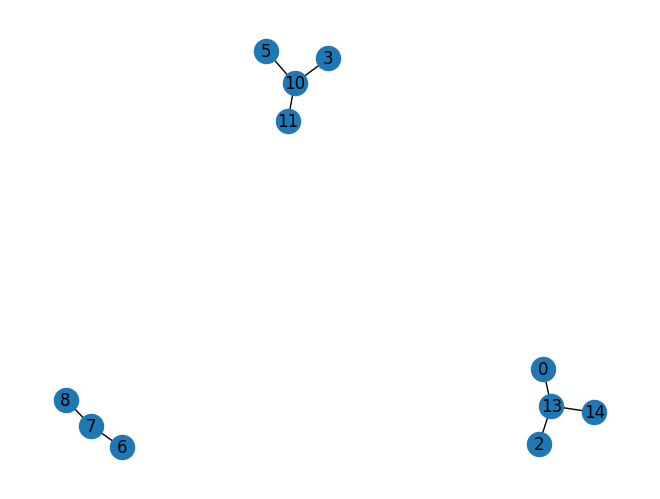

fusion  (5, 6)  success
in dfs for graph with nodes [0, 2, 3, 7, 8, 10, 11, 13, 14] fusion order [(4, 9), (1, 12), (5, 6), (2, 3)]


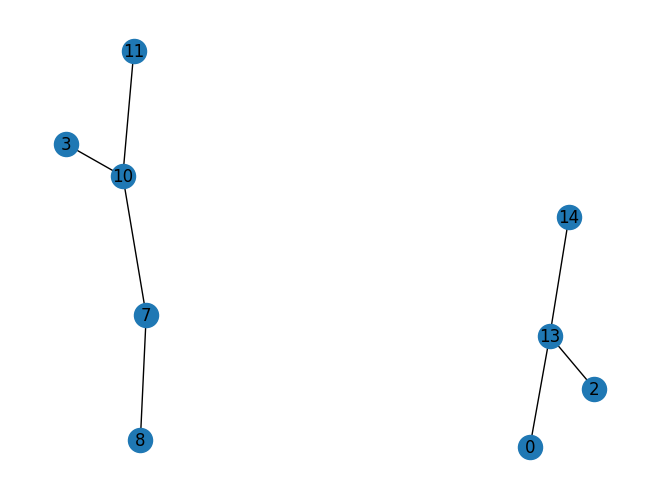

fusion  (2, 3)  success
in dfs for graph with nodes [0, 7, 8, 10, 11, 13, 14] fusion order [(4, 9), (1, 12), (5, 6), (2, 3)]


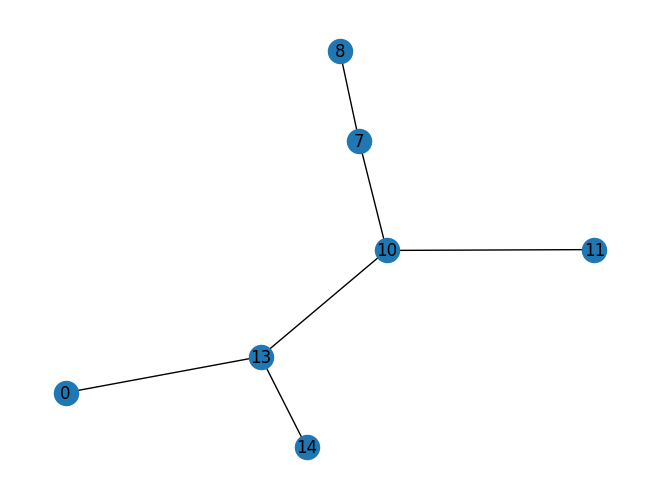

fusion failure  2 3
rebuilding vertex 2
connected components for neighbor 13 : {0, 13, 14}
set initial ghz as  (2, 13, 18) fusing the last with neighbor 13
rebuilding vertex 3
connected components for neighbor 10 : {8, 10, 11, 7}
set initial ghz as  (3, 10, 21) fusing the last with neighbor 10
vertex map: {2: 17, 13: 16, 3: 20, 10: 19}
> /home/korbinian/Code/vdsp/firstpassage/FPTCalculator.py(247)dfs()
    245             # print("before",intermediate_source_order)
    246             # print("after",target_order)
--> 247             min_swaps = find_min_swaps_after_failure(intermediate_source_order, target_order)
    248             pcvl.pdisplay(build_swap_circuit(reversed(min_swaps), num_qubits)).save_svg("failure"+str(v1)+str(v2)+".svg")
    249             # import pdb

ipdb> source_order
[0, 7, 8, 4, 9, 10, 11, 1, 12, 5, 6, 2, 3, 13, 14]
ipdb> target_order
[0, 7, 8, 4, 9, 11, 1, 12, 5, 6, 2, 3, 14, 13, 15, 16, 10, 18, 19, 17, 20]
ipdb> current_fusion_order
[(4, 9), (1, 12), (13, 

In [ ]:
print(get_fp_times(fusion_order, 15, [0.5,0.66,0.75,0.85,1], draw_circuits=True, verbose=True))